In [1]:
from pathlib import Path

BASE = Path.cwd() # .../dash_topology/notebooks
DATADIR_ROOT = BASE.parent / "datadir"

print("Notebook cwd:", BASE)
print("Datadir root:", DATADIR_ROOT)
print("Exists?", DATADIR_ROOT.exists())

runs = sorted(DATADIR_ROOT.glob("run_*"))
print("Runs:", [p.name for p in runs])


Notebook cwd: /home/arthur.barbabella/lft/onos_topologies/dash_topology/notebooks
Datadir root: /home/arthur.barbabella/lft/onos_topologies/dash_topology/datadir
Exists? True
Runs: ['run_2025-11-21_10-30-44']


In [2]:
RUN_ROOT = runs[-1]

print("Using RUN_ROOT:", RUN_ROOT)

iters = sorted(RUN_ROOT.glob("iter_*"))
print("Iterations found:", len(iters))
iters[:3]

Using RUN_ROOT: /home/arthur.barbabella/lft/onos_topologies/dash_topology/datadir/run_2025-11-21_10-30-44
Iterations found: 29


[PosixPath('/home/arthur.barbabella/lft/onos_topologies/dash_topology/datadir/run_2025-11-21_10-30-44/iter_0000'),
 PosixPath('/home/arthur.barbabella/lft/onos_topologies/dash_topology/datadir/run_2025-11-21_10-30-44/iter_0001'),
 PosixPath('/home/arthur.barbabella/lft/onos_topologies/dash_topology/datadir/run_2025-11-21_10-30-44/iter_0002')]

In [3]:
import gzip, json
import pandas as pd

def read_client_gz(path: Path):
    with gzip.open(path, "rt", encoding="utf-8") as f:
        data = json.load(f)

    # formato 1: lista direta
    if isinstance(data, list):
        return data

    # formato 2: dict com "client"
    if isinstance(data, dict):
        return data.get("client", [])

    return []


In [4]:
records = []

for iter_path in iters:
    iter_name = iter_path.name # iter_0000, iter_0001...
    clients_dir = iter_path / "clients"

    for gz_file in sorted(clients_dir.glob("*.json.gz")):
        cname = gz_file.name.replace(".json.gz", "") # cl0, cl1...
        rows = read_client_gz(gz_file)

        for r in rows:
            r2 = dict(r)
            r2["iter_round"] = iter_name
            r2["client"] = cname
            records.append(r2)

df = pd.DataFrame(records)
print("rows:", len(df))
df.head()


rows: 11745


,connect_time,delta_sys_time,delta_user_time,elapsed,elapsed_target,internal_address,iteration,platform,rate,real_address,received,remote_address,request_ticks,server_url,timestamp,uuid,version,iter_round,client
0,0,0,0,0.141118,2,,0,linux,3000,192.168.0.2,750000,,0.045732,http://192.168.0.1/dash/download/750000,1763721044,,0.008000000,iter_0000,cl0
1,0,0,0,0.170334,2,,1,linux,42517,192.168.0.2,7500000,,0.186935,http://192.168.0.1/dash/download/10629250,1763721045,,0.008000000,iter_0000,cl0
2,0,0,0,0.142677,2,,2,linux,352248,192.168.0.2,7500000,,0.357394,http://192.168.0.1/dash/download/88062000,1763721045,,0.008000000,iter_0000,cl0
3,0,0,0,0.152712,2,,3,linux,420530,192.168.0.2,7500000,,0.500169,http://192.168.0.1/dash/download/105132500,1763721045,,0.008000000,iter_0000,cl0
4,0,0,0,0.144386,2,,4,linux,392897,192.168.0.2,7500000,,0.652976,http://192.168.0.1/dash/download/98224250,1763721045,,0.008000000,iter_0000,cl0


In [5]:
df["round_idx"] = df["iter_round"].str.extract(r"iter_(\d+)").astype(int)

# estimated throughput
df["throughput_Bps"] = df["received"] / df["elapsed"]
df["throughput_Mbps"] = (df["throughput_Bps"] * 8) / 1e6

df[["round_idx","client","elapsed","rate","throughput_Mbps"]].head()

,round_idx,client,elapsed,rate,throughput_Mbps
0,0,cl0,0.141118,3000,42.517639
1,0,cl0,0.170334,42517,352.248726
2,0,cl0,0.142677,352248,420.530206
3,0,cl0,0.152712,420530,392.897238
4,0,cl0,0.144386,392897,415.554179


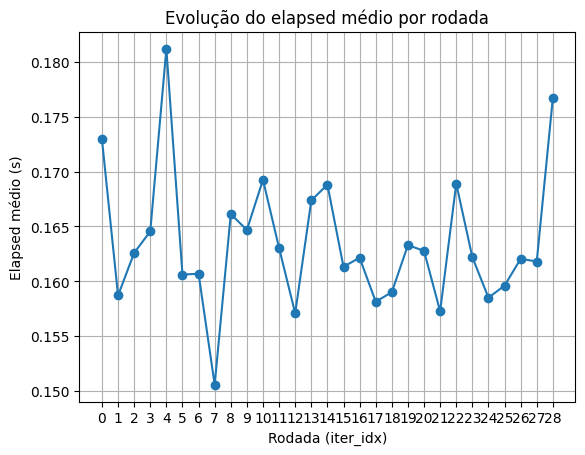

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

g = df.groupby("round_idx")["elapsed"].mean().reset_index()
x = g["round_idx"].astype(int)

plt.figure()
plt.plot(x, g["elapsed"], marker="o")
plt.xlabel("Rodada (iter_idx)")
plt.ylabel("Elapsed médio (s)")
plt.title("Evolução do elapsed médio por rodada")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  
plt.xticks(x) 

plt.show()

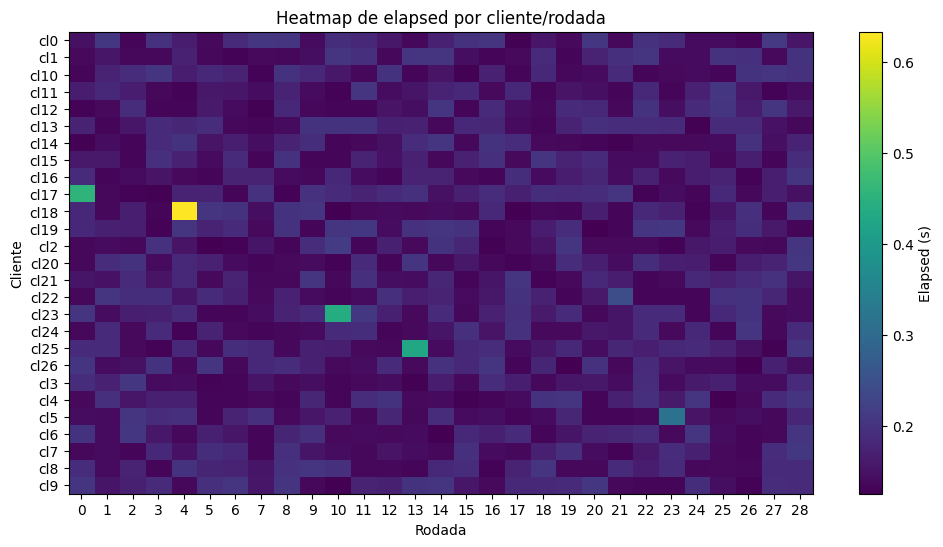

In [7]:
pivot = df.pivot_table(index="client", columns="round_idx", values="elapsed", aggfunc="mean")

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Elapsed (s)")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Rodada")
plt.ylabel("Cliente")
plt.title("Heatmap de elapsed por cliente/rodada")
plt.show()
